# **Lab 04.1 - Policy-Based Reinforcement Learning on CartPole-v1**


##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>

This notebook focuses on policy-based RL methods on CartPole-v1:
<ol style="margin-left: 20px;">
  <li><strong>Part 1: Random policy baseline</strong> </li>
  <li><strong>Part 2: REINFORCE</strong> </li>
  <li><strong>Part 3: Actor-Critic</strong></li>
  <li><strong>Part 4: A2C (Stable-Baselines3)</strong> </li>
</ol>
</div>


### Imports and Setup

The following cell configures the runtime and defines shared utilities used across all parts of this lab.

In [14]:
# Runtime stability settings for notebook environments on macOS
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

# Core libraries
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

# Keep CPU thread usage predictable in notebook kernels
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

# Reproducibility settings
SEED = 42
FAST_MODE = True

# Set seeds for all libraries to ensure reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cpu' if torch.cuda.is_available() else 'cpu')

# Matplotlib settings for cleaner plots
plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.grid': True,
    'grid.alpha': 0.25,
})

print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')
print(f'NumPy: {np.__version__}')
print(f'Gymnasium: {gym.__version__}')
print(f'FAST_MODE: {FAST_MODE}')

Device: cpu
PyTorch: 2.5.1+cu121
NumPy: 2.4.2
Gymnasium: 1.2.3
FAST_MODE: True


## Utility Functions

This section defines shared helper functions used throughout the notebook:

- **`make_cartpole_env()`** creates a CartPole-v1 environment with deterministic seeding.
- **`moving_average()`** smooths episode rewards for clearer learning curves.
- **`plot_learning_curve()`** visualizes both raw returns and smoothed performance over time.

These utilities are reused in the baseline, REINFORCE, and Actor-Critic experiments.

In [15]:
# Utility functions for environment setup, plotting, and evaluation
def make_cartpole_env(seed_offset=0):
    """Create CartPole-v1 with deterministic reset/action seeds."""
    env = gym.make('CartPole-v1')
    env.reset(seed=SEED + seed_offset)
    env.action_space.seed(SEED + seed_offset)
    return env

# Moving average and plotting utilities
def moving_average(values, window=20):
    """Compute a simple moving average for smoother learning curves."""
    if len(values) == 0:
        return np.array([])
    return pd.Series(values).rolling(window=window, min_periods=1).mean().to_numpy()

# Plotting function for learning curves
def plot_learning_curve(values, title, ylabel, window=20):
    """Plot raw episode values and moving average in one figure."""
    x = np.arange(1, len(values) + 1)
    plt.figure(figsize=(10, 4))
    plt.plot(x, values, alpha=0.35, label='Episode value')
    plt.plot(x, moving_average(values, window), linewidth=2, label=f'{window}-episode moving average')
    plt.title(title)
    plt.xlabel('Episode')
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()

---

# PART 1: CartPole Baselines

We start with simple baselines to understand the expected return scale and variance.



### 1.1 Policy Evaluation Helper

This block defines a reusable function, `evaluate_cartpole_policy(action_fn, episodes=20)`, to measure policy performance on **CartPole-v1**.

- Runs multiple evaluation episodes (default: 20).
- Creates a freshly seeded environment each episode for reproducible results.
- Uses `action_fn(state, env)` to choose actions, so it works with random, REINFORCE, Actor-Critic, or A2C policies.
- Accumulates total reward per episode until termination/truncation.
- Returns all episode returns as a NumPy array (`float32`) for later statistics and comparison.

In [16]:
# Evaluation function for any CartPole policy
def evaluate_cartpole_policy(action_fn, episodes=20):
    """Evaluate any action function on CartPole and return episode returns."""
    returns = []
    for ep in range(episodes):
        env = make_cartpole_env(seed_offset=1000 + ep)
        state, _ = env.reset(seed=SEED + 1000 + ep)

        done = False
        total_reward = 0.0
        while not done:
            action = int(action_fn(state, env))
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated

        returns.append(total_reward)
        env.close()

    return np.array(returns, dtype=np.float32)

### 1.2 Random Policy Baseline

Average return: 27.45
Min return: 9.00
Max return: 93.00


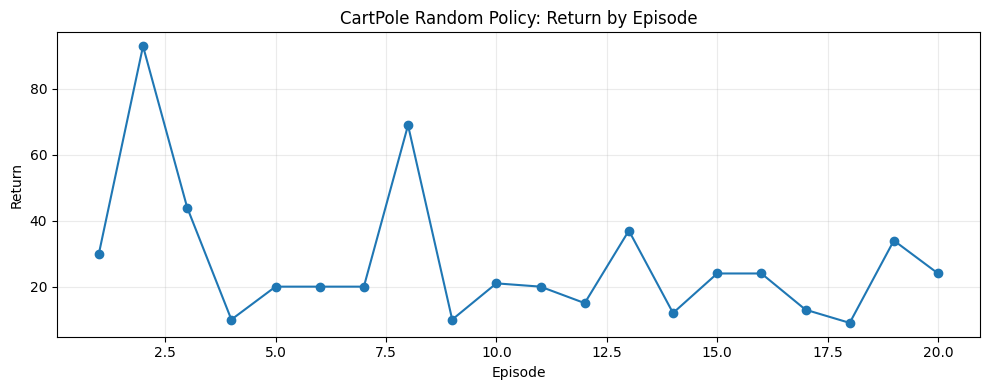

In [17]:
# ============================================================================
# Random policy baseline
# ============================================================================

random_returns = []

for ep in range(20):
    # Create a fresh environment with deterministic seeds
    env = make_cartpole_env(seed_offset=ep)
    state, _ = env.reset(seed=SEED + ep)

    done = False
    episode_return = 0.0

    # Rollout one episode using random actions
    while not done:
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        action = env.action_space.sample() 
        state, reward, terminated, truncated, _ = env.step(action)
        episode_return += reward
        done = terminated or truncated

    random_returns.append(episode_return)
    env.close()

random_returns = np.array(random_returns, dtype=np.float32)

print(f'Average return: {random_returns.mean():.2f}')
print(f'Min return: {random_returns.min():.2f}')
print(f'Max return: {random_returns.max():.2f}')

# Visualize episode-level returns
plt.figure(figsize=(10, 4))
plt.plot(np.arange(1, 21), random_returns, marker='o')
plt.title('CartPole Random Policy: Return by Episode')
plt.xlabel('Episode')
plt.ylabel('Return')
plt.tight_layout()
plt.show()

---

# PART 2: REINFORCE (Policy Gradient)

REINFORCE is a Monte Carlo policy-gradient method.

### 2.1 REINFORCE helper components

- **PolicyNetwork**  
    - Simple MLP: Linear(4 → 128) → ReLU → Linear(128 → 2) → Softmax.  
    - Inputs: state tensor (batch or single); Output: action probability vector.

- **select_action(policy_net, state)**  
    - Converts a single state (numpy array) to a device tensor, queries policy_net, builds a Categorical distribution, samples an action.  
    - Returns: (action: int, log_prob: torch.Tensor) where log_prob is used for policy-gradient updates.

- **compute_discounted_returns(rewards, gamma=0.99, normalize=True)**  
    - Produces Monte Carlo discounted returns by reverse accumulation: G_t = r_t + gamma * G_{t+1}.  
    - Returns a torch.float32 tensor on the global device. If normalize=True and more than one value, returns are standardized (zero mean, unit std) with numeric stability eps.

- Notes: these utilities assume the global `device` and are designed to be called inside the REINFORCE training loop (collect log-probs, compute returns, form -log_prob * G loss).

In [18]:
# REINFORCE policy network
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.net(x)

# Action selection function for REINFORCE
def select_action(policy_net, state):
    """Sample one action from policy distribution and return log-probability."""

    # Convert state to tensor and get action probabilities from policy network
    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    state_tensor = torch.tensor(state, dtype=torch.float32, device=device)
    probs = policy_net(state_tensor)

    # Create a categorical distribution and sample an action
    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    dist = Categorical(probs)
    action = dist.sample()
    return int(action.item()), dist.log_prob(action)

# Function to compute discounted returns for REINFORCE
def compute_discounted_returns(rewards, gamma=0.99, normalize=True):
    """Compute discounted returns and optionally normalize them."""
    returns = []
    discounted_sum = 0.0
    for reward in reversed(rewards):
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        discounted_sum = reward + gamma * discounted_sum
        # Insert the discounted sum at the beginning of the list
        returns.insert(0, discounted_sum)

    returns = torch.tensor(returns, dtype=torch.float32, device=device)
    # Normalize returns for better training stability
    if normalize and returns.numel() > 1:
        returns = (returns - returns.mean()) / (returns.std(unbiased=False) + 1e-8)
    return returns

### 2.2 Training with REINFORCE

Main idea:
- Sample trajectories from the current policy.
- Compute discounted returns.
- Update the policy using the objective $-log \pi(a_t|s_t) G_t$.

In [19]:
# ============================================================================
# REINFORCE training loop
# ============================================================================

# Train REINFORCE on CartPole-v1
def train_reinforce_cartpole(episodes, gamma=0.99, lr=1e-3):
    # Policy network and optimizer
    policy_net = PolicyNetwork(input_dim=4, hidden_dim=128, output_dim=2).to(device)
    optimizer = optim.Adam(policy_net.parameters(), lr=lr)

    episode_returns = []

    for ep in range(episodes):
        env = make_cartpole_env(seed_offset=2000 + ep)
        state, _ = env.reset(seed=SEED + 2000 + ep)

        log_probs = []
        rewards = []
        total_reward = 0.0
        done = False

        # Collect one full episode
        while not done:
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            action, log_prob = select_action(policy_net, state)
            state, reward, terminated, truncated, _ = env.step(action)
            log_probs.append(log_prob)
            rewards.append(reward)
            total_reward += reward
            done = terminated or truncated

        # Compute Monte Carlo returns
        returns = compute_discounted_returns(rewards, gamma=gamma, normalize=True)

        # Policy gradient loss for one episode
        loss = 0.0
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        for log_prob, Gt in zip(log_probs, returns):
            loss += -log_prob * Gt

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        episode_returns.append(total_reward)
        env.close()

        if (ep + 1) % 50 == 0:
            print(f'REINFORCE episode {ep + 1}/{episodes} | return: {total_reward:.1f}')

    return policy_net, episode_returns

This cell runs and checks **REINFORCE** on **CartPole-v1**.

REINFORCE episode 50/300 | return: 13.0
REINFORCE episode 100/300 | return: 19.0
REINFORCE episode 150/300 | return: 40.0
REINFORCE episode 200/300 | return: 189.0
REINFORCE episode 250/300 | return: 47.0
REINFORCE episode 300/300 | return: 247.0


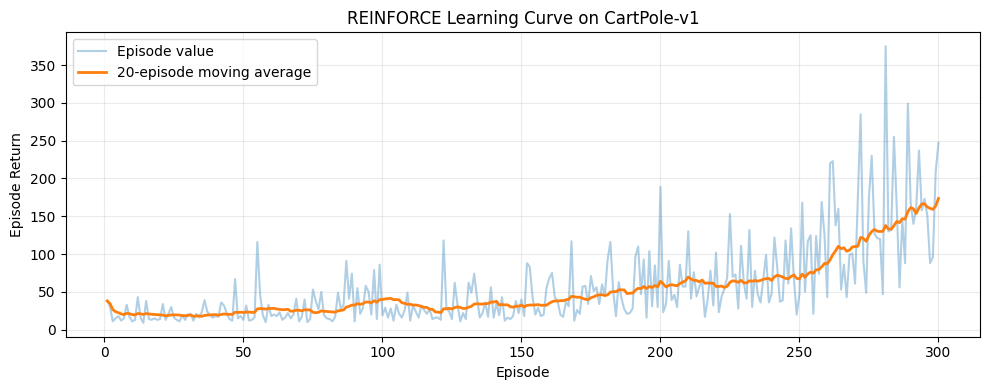

REINFORCE avg return: 320.00
REINFORCE std return: 95.30
REINFORCE max return: 500.00


In [20]:
# Train REINFORCE
reinforce_episodes = 300 if FAST_MODE else 1000
reinforce_policy, reinforce_train_returns = train_reinforce_cartpole(episodes=reinforce_episodes)

plot_learning_curve(
    reinforce_train_returns,
    title='REINFORCE Learning Curve on CartPole-v1',
    ylabel='Episode Return',
    window=20,
)

# Deterministic evaluation for fair comparison

def reinforce_action_fn(state, env=None):
    with torch.no_grad():
        state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        probs = reinforce_policy(state_tensor).squeeze(0)
        return int(torch.argmax(probs).item())


reinforce_eval_returns = evaluate_cartpole_policy(reinforce_action_fn, episodes=20)
print(f'REINFORCE avg return: {reinforce_eval_returns.mean():.2f}')
print(f'REINFORCE std return: {reinforce_eval_returns.std():.2f}')
print(f'REINFORCE max return: {reinforce_eval_returns.max():.2f}')

---

# PART 3: Actor-Critic Methods

Actor-Critic combines a policy (actor) and a value estimator (critic).

### 3.1 Actor-Critic from Scratch

Actor-Critic uses two models:

- **Actor**: outputs action probabilities $\pi(a \mid s)$
- **Critic**: estimates the state value $V(s)$


#### Actor-Critic Model Definitions

This code block defines two neural networks for the Actor-Critic method on CartPole:

- **ActorNetwork**: takes the state as input and outputs action probabilities (`left` or `right`) using a Softmax layer.
- **CriticNetwork**: takes the state as input and predicts a single state-value estimate \(V(s)\).

Both networks use a simple MLP architecture:  
`Linear(4 → 128) → ReLU → Linear(...)`.

These models are later used together in the training loop, where:
- the **actor** learns the policy,
- the **critic** provides value-based feedback for more stable updates.

In [21]:
# Actor-Critic models
class ActorNetwork(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.net(x)


class CriticNetwork(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

Update equations:

$$\text{TD target} = r + \gamma V(s') (1 - \text{done})$$

$$\delta = \text{TD target} - V(s)$$

$$\mathcal{L}_{\text{actor}} = -\log \pi(a \mid s) \cdot \delta$$

$$\mathcal{L}_{\text{critic}} = \left(V(s) - \text{TD target}\right)^2$$

In [22]:
# ============================================================================
# Actor-Critic training loop
# ============================================================================

def train_actor_critic_cartpole(episodes, gamma=0.99, actor_lr=1e-3, critic_lr=1e-3):
    # Actor and critic networks
    actor = ActorNetwork(input_dim=4, hidden_dim=128, output_dim=2).to(device)
    critic = CriticNetwork(input_dim=4, hidden_dim=128, output_dim=1).to(device)

    actor_optimizer = optim.Adam(actor.parameters(), lr=actor_lr)
    critic_optimizer = optim.Adam(critic.parameters(), lr=critic_lr)

    episode_returns = []

    for ep in range(episodes):
        env = make_cartpole_env(seed_offset=3000 + ep)
        state, _ = env.reset(seed=SEED + 3000 + ep)

        total_reward = 0.0
        done = False

        # One episode of online actor-critic updates
        while not done:
            # Convert state to tensor and get action probabilities from actor network
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            probs = actor(state_tensor).squeeze(0)
            # Create a categorical distribution and sample an action
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            dist = Categorical(probs)
            action_tensor = dist.sample()
            log_prob = dist.log_prob(action_tensor)

            # Get value estimate from critic network
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            value = critic(state_tensor).squeeze(0)
            next_state, reward, terminated, truncated, _ = env.step(int(action_tensor.item()))
            done = terminated or truncated
            
            next_state_tensor = torch.tensor(next_state, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                ### YOU NEED TO WRITE YOUR CODE BELOW ###
                next_value = critic(next_state_tensor).squeeze(0)

            done_float = 1.0 if done else 0.0
            # Compute TD target 
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            td_target = reward + gamma * next_value * (1 - done_float)
            delta = td_target - value

            # Compute actor and critic losses
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            actor_loss = -log_prob * delta.detach()
            critic_loss = nn.functional.mse_loss(value, td_target.detach())

            actor_optimizer.zero_grad()
            actor_loss.backward()
            actor_optimizer.step()

            critic_optimizer.zero_grad()
            critic_loss.backward()
            critic_optimizer.step()

            state = next_state
            total_reward += reward

        episode_returns.append(total_reward)
        env.close()

        if (ep + 1) % 50 == 0:
            print(f'Actor-Critic episode {ep + 1}/{episodes} | return: {total_reward:.1f}')

    return actor, critic, episode_returns

This cell runs and checks **Actor-Critic** on **CartPole-v1**.

Actor-Critic episode 50/300 | return: 11.0
Actor-Critic episode 100/300 | return: 10.0
Actor-Critic episode 150/300 | return: 13.0
Actor-Critic episode 200/300 | return: 59.0
Actor-Critic episode 250/300 | return: 269.0
Actor-Critic episode 300/300 | return: 119.0


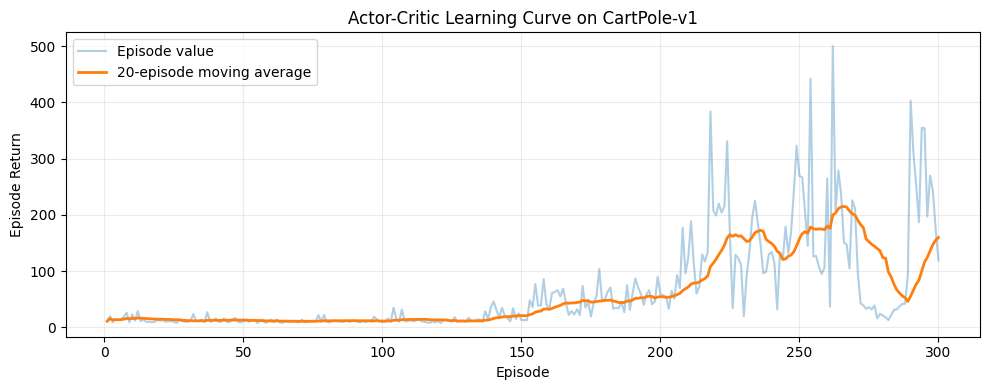

Actor-Critic avg return: 122.75
Actor-Critic std return: 9.19
Actor-Critic max return: 142.00


In [23]:
# Train Actor-Critic
actor_critic_episodes = 300 if FAST_MODE else 1000
actor_model, critic_model, actor_critic_train_returns = train_actor_critic_cartpole(episodes=actor_critic_episodes)

plot_learning_curve(
    actor_critic_train_returns,
    title='Actor-Critic Learning Curve on CartPole-v1',
    ylabel='Episode Return',
    window=20,
)

# Deterministic evaluation for fair comparison

def actor_critic_action_fn(state, env=None):
    with torch.no_grad():
        state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        probs = actor_model(state_tensor).squeeze(0)
        return int(torch.argmax(probs).item())


actor_critic_eval_returns = evaluate_cartpole_policy(actor_critic_action_fn, episodes=20)
print(f'Actor-Critic avg return: {actor_critic_eval_returns.mean():.2f}')
print(f'Actor-Critic std return: {actor_critic_eval_returns.std():.2f}')
print(f'Actor-Critic max return: {actor_critic_eval_returns.max():.2f}')

---

# PART 4: Advantage Actor Critic (A2C) Methods

If Stable-Baselines3 is available, train A2C with `MlpPolicy`. Otherwise, this cell prints the install guidance and continues.

In [24]:
# ============================================================================
# A2C baseline (Stable-Baselines3)
# ============================================================================

a2c_available = False
a2c_eval_returns = None

try:
    from stable_baselines3 import A2C
    
    a2c_available = True
    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    train_env = gym.make('CartPole-v1')
    train_env.reset(seed=SEED + 4000)
    train_env.action_space.seed(SEED + 4000)

    total_timesteps = 15000 if FAST_MODE else 50000
    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    a2c_model = A2C('MlpPolicy', train_env, seed=SEED + 4000, verbose=0)
    a2c_model.learn(total_timesteps=total_timesteps)

    # Deterministic action for evaluation
    def a2c_action_fn(state, env=None):
        action, _ = a2c_model.predict(state, deterministic=True)
        return int(action)

    a2c_eval_returns = evaluate_cartpole_policy(a2c_action_fn, episodes=20)
    print(f'A2C avg return: {a2c_eval_returns.mean():.2f}')
    print(f'A2C std return: {a2c_eval_returns.std():.2f}')
    print(f'A2C max return: {a2c_eval_returns.max():.2f}')

    train_env.close()

except Exception as e:
    print('Stable-Baselines3 is not available or failed to run.')
    print('Install with: pip install stable-baselines3')
    print(f'Details: {e}')

c:\Users\VAN TAI\.conda\envs\nt549-05-vantai\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


A2C avg return: 499.10
A2C std return: 3.70
A2C max return: 500.00


### 4.1 Final Comparison

We summarize the baseline and policy-based results in a single table and plot.

,Method,Avg Return,Std Return,Max Return
0,A2C,499.100006,3.700000,500.0
1,REINFORCE,320.000000,95.296379,500.0
2,Actor-Critic,122.750000,9.191709,142.0
3,Random,27.450001,20.357985,93.0


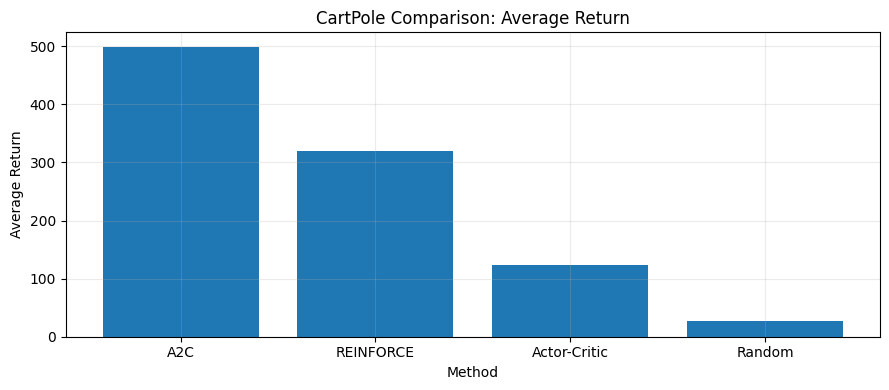

In [25]:
# ============================================================================
# Final comparison table and plot
# ============================================================================

comparison_rows = []


def add_cartpole_result(method_name, returns):
    comparison_rows.append({
        'Method': method_name,
        'Avg Return': float(np.mean(returns)),
        'Std Return': float(np.std(returns)),
        'Max Return': float(np.max(returns)),
    })


add_cartpole_result('Random', random_returns)
add_cartpole_result('REINFORCE', reinforce_eval_returns)
add_cartpole_result('Actor-Critic', actor_critic_eval_returns)

if a2c_available and a2c_eval_returns is not None:
    add_cartpole_result('A2C', a2c_eval_returns)

cartpole_comparison_df = pd.DataFrame(comparison_rows)
cartpole_comparison_df = cartpole_comparison_df.sort_values(by='Avg Return', ascending=False).reset_index(drop=True)

display(cartpole_comparison_df)

plt.figure(figsize=(9, 4))
plt.bar(cartpole_comparison_df['Method'], cartpole_comparison_df['Avg Return'])
plt.title('CartPole Comparison: Average Return')
plt.xlabel('Method')
plt.ylabel('Average Return')
plt.tight_layout()
plt.show()

Starting multi-seed experiment...

=== Seed 42 ===
  Training REINFORCE...
  Training Actor-Critic...

=== Seed 123 ===
  Training REINFORCE...
  Training Actor-Critic...

=== Seed 456 ===
  Training REINFORCE...
  Training Actor-Critic...

=== Seed 789 ===
  Training REINFORCE...
  Training Actor-Critic...

=== Seed 1000 ===
  Training REINFORCE...
  Training Actor-Critic...


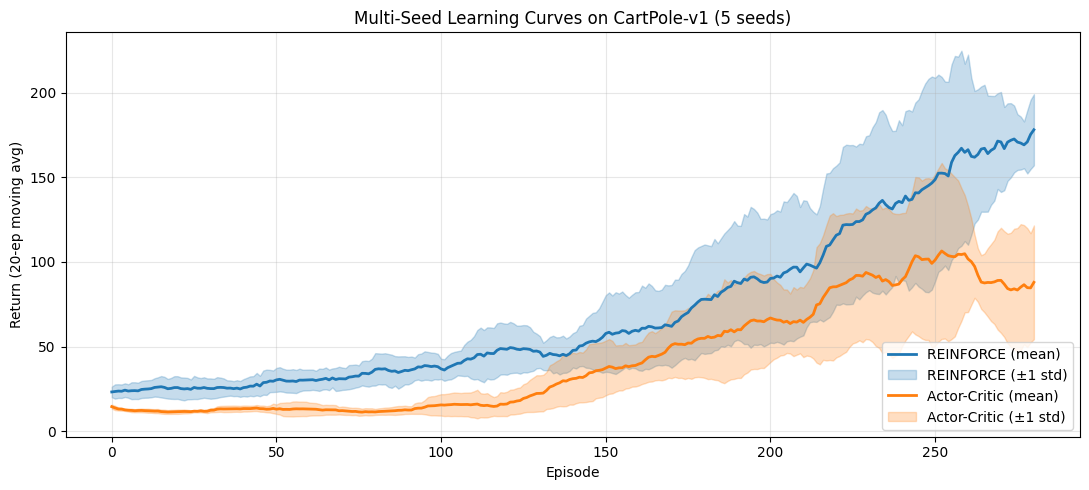


Algorithm         Final Mean    Final Std    Best Mean
REINFORCE             166.32        40.42       263.40
Actor-Critic           95.29        26.63       173.80

Done! See 'multi_seed_comparison.png'


In [26]:
"""
Multi-Seed Experiment for Lab 04.1

"""

import numpy as np
import matplotlib.pyplot as plt
import torch
import gymnasium as gym
import random
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

# ============================================================================
# Cấu hình experiment
# ============================================================================
SEEDS = [42, 123, 456, 789, 1000] 
EPISODES = 300  # Giảm để tiết kiệm thời gian; nếu có thời gian dùng 500-1000
device = torch.device('cpu' if torch.cuda.is_available() else 'cpu')


# ============================================================================
# Helper: Set seed cho toàn bộ
# ============================================================================
def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# ============================================================================
# Định nghĩa lại các networks (để script chạy độc lập)
# ============================================================================
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Softmax(dim=-1),
        )

    def forward(self, x):
        return self.net(x)


class ActorNetwork(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Softmax(dim=-1),
        )

    def forward(self, x):
        return self.net(x)


class CriticNetwork(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


# ============================================================================
# Training functions (rút gọn)
# ============================================================================
def train_reinforce_one_seed(seed, episodes=300, gamma=0.99, lr=1e-3):
    set_global_seed(seed)
    policy_net = PolicyNetwork().to(device)
    optimizer = optim.Adam(policy_net.parameters(), lr=lr)
    episode_returns = []

    for ep in range(episodes):
        env = gym.make('CartPole-v1')
        state, _ = env.reset(seed=seed + ep)

        log_probs, rewards = [], []
        total_reward, done = 0.0, False

        while not done:
            state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            probs = policy_net(state_tensor).squeeze(0)
            dist = Categorical(probs)
            action = dist.sample()
            log_probs.append(dist.log_prob(action))

            state, reward, terminated, truncated, _ = env.step(int(action.item()))
            rewards.append(reward)
            total_reward += reward
            done = terminated or truncated

        # Compute discounted returns
        returns = []
        G = 0.0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.tensor(returns, dtype=torch.float32, device=device)
        if returns.numel() > 1:
            returns = (returns - returns.mean()) / (returns.std(unbiased=False) + 1e-8)

        loss = 0.0
        for lp, Gt in zip(log_probs, returns):
            loss += -lp * Gt

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        episode_returns.append(total_reward)
        env.close()

    return episode_returns


def train_actor_critic_one_seed(seed, episodes=300, gamma=0.99, actor_lr=1e-3, critic_lr=1e-3):
    set_global_seed(seed)
    actor = ActorNetwork().to(device)
    critic = CriticNetwork().to(device)
    a_opt = optim.Adam(actor.parameters(), lr=actor_lr)
    c_opt = optim.Adam(critic.parameters(), lr=critic_lr)
    episode_returns = []

    for ep in range(episodes):
        env = gym.make('CartPole-v1')
        state, _ = env.reset(seed=seed + ep)
        total_reward, done = 0.0, False

        while not done:
            state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            probs = actor(state_tensor).squeeze(0)
            dist = Categorical(probs)
            action_tensor = dist.sample()
            log_prob = dist.log_prob(action_tensor)
            value = critic(state_tensor).squeeze(0)

            next_state, reward, terminated, truncated, _ = env.step(int(action_tensor.item()))
            done = terminated or truncated

            next_state_tensor = torch.tensor(next_state, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                next_value = critic(next_state_tensor).squeeze(0)

            done_float = 1.0 if done else 0.0
            td_target = reward + gamma * next_value * (1.0 - done_float)
            delta = td_target - value

            actor_loss = -log_prob * delta.detach()
            critic_loss = nn.functional.mse_loss(value, td_target.detach())

            a_opt.zero_grad()
            actor_loss.backward()
            a_opt.step()

            c_opt.zero_grad()
            critic_loss.backward()
            c_opt.step()

            state = next_state
            total_reward += reward

        episode_returns.append(total_reward)
        env.close()

    return episode_returns


# ============================================================================
# Chạy multi-seed
# ============================================================================
def run_multi_seed_experiment():
    results = {'REINFORCE': [], 'Actor-Critic': []}

    for seed in SEEDS:
        print(f"\n=== Seed {seed} ===")

        print(f"  Training REINFORCE...")
        r = train_reinforce_one_seed(seed, episodes=EPISODES)
        results['REINFORCE'].append(r)

        print(f"  Training Actor-Critic...")
        ac = train_actor_critic_one_seed(seed, episodes=EPISODES)
        results['Actor-Critic'].append(ac)

    return results


def plot_multi_seed_curves(results, window=20):
    """Vẽ reward curve với shaded variance region — chuẩn academic."""
    fig, ax = plt.subplots(figsize=(11, 5))
    colors = {'REINFORCE': 'tab:blue', 'Actor-Critic': 'tab:orange'}

    for algo, runs in results.items():
        # runs: list of length n_seeds, each is list of episode returns
        runs_array = np.array(runs)  # shape: (n_seeds, n_episodes)
        # Smooth từng seed bằng moving average
        smoothed = np.array([
            np.convolve(r, np.ones(window)/window, mode='valid')
            for r in runs_array
        ])
        mean = smoothed.mean(axis=0)
        std = smoothed.std(axis=0)
        x = np.arange(len(mean))

        ax.plot(x, mean, label=f'{algo} (mean)', color=colors[algo], linewidth=2)
        ax.fill_between(x, mean - std, mean + std, alpha=0.25, color=colors[algo],
                        label=f'{algo} (±1 std)')

    ax.set_xlabel('Episode')
    ax.set_ylabel(f'Return ({window}-ep moving avg)')
    ax.set_title(f'Multi-Seed Learning Curves on CartPole-v1 ({len(SEEDS)} seeds)')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('multi_seed_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


def print_summary_statistics(results):
    """Bảng thống kê chuẩn academic."""
    print("\n" + "="*70)
    print(f"{'Algorithm':<15} {'Final Mean':>12} {'Final Std':>12} {'Best Mean':>12}")
    print("="*70)
    for algo, runs in results.items():
        runs_array = np.array(runs)
        # Lấy 50 episode cuối để đo "performance ổn định"
        final_returns = runs_array[:, -50:].mean(axis=1)
        final_mean = final_returns.mean()
        final_std = final_returns.std()
        best_mean = runs_array.mean(axis=0).max()
        print(f"{algo:<15} {final_mean:>12.2f} {final_std:>12.2f} {best_mean:>12.2f}")
    print("="*70)


if __name__ == '__main__':
    print("Starting multi-seed experiment...")
    results = run_multi_seed_experiment()
    plot_multi_seed_curves(results)
    print_summary_statistics(results)
    print("\nDone! See 'multi_seed_comparison.png'")

## CONGRATULATIONS TEAM!

Congratulations on Completing Lab 04.1 - Policy-Based Reinforcement Learning on CartPole-v1!

You have successfully implemented and compared multiple policy-based reinforcement learning algorithms:
- Established a performance baseline with random action selection
- Implemented REINFORCE learning with discounted returns
- Built a two-network architecture (Actor + Critic) and temporal difference learning for stable updates
- Used A2C with Stable-Baselines3

You are ready to apply these techniques to more complex environments and real-world problems!

References: https://gymnasium.farama.org/ | https://pytorch.org/ | https://stable-baselines3.readthedocs.io/

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn

**Last Updated**: March, 2026